In [1]:
import os
import pandas as pd
import numpy as np

def read_first_existing(*paths):
    for p in paths:
        if os.path.exists(p):
            return pd.read_pickle(p)
    raise FileNotFoundError(f"None of these files exists: {paths}")

In [6]:
path = 'E:/yjz/Extension for hts/JayCode/Models/'
base = pd.concat([pd.read_pickle("lgbInvtSim_L1.pkl"), pd.read_pickle("etsInvtSim_L1.pkl")])
bu   = pd.read_pickle("BUOrder_L1.pkl")
tdfp = pd.read_pickle("TDFPOrder_L1.pkl")
mint = pd.read_pickle("VarOrder_L1.pkl")

uid  = pd.read_pickle(f"{path}721future_28.pkl")
tag  = pd.read_pickle(f"{path}tags.bin")
ao   = pd.read_pickle("actual_order.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'actual_order.pkl'

In [2]:
path = 'E:/yjz/Extension for hts/JayCode/Models/'

prd_idx = pd.read_pickle(f"{}prd_idx.pkl")
tsl = ['90', '95', '99']

lgb = read_first_existing("lgbInvtSim_L1.pkl", "lgbInvtSim_L1.pkl")
ets = read_first_existing("etsInvtSim_L1.pkl", "etsInvtSim_L1.pkl")

lgb_methods = list(lgb['name'].unique())
ets_methods = list(ets['name'].unique())
uid  = pd.read_pickle(f"{path}721future_28.pkl")[['unique_id','ds']]

prd_idx = pd.read_pickle("prd_idx.pkl")
prd_list = list(prd_idx.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'prd_idx.pkl'

In [4]:
prd_list

['FOODS_1_001',
 'FOODS_1_002',
 'FOODS_1_003',
 'FOODS_1_004',
 'FOODS_1_005',
 'FOODS_1_006',
 'FOODS_1_008',
 'FOODS_1_009',
 'FOODS_1_010',
 'FOODS_1_011',
 'FOODS_1_012',
 'FOODS_1_013',
 'FOODS_1_014',
 'FOODS_1_015',
 'FOODS_1_016',
 'FOODS_1_017',
 'FOODS_1_018',
 'FOODS_1_019',
 'FOODS_1_020',
 'FOODS_1_021',
 'FOODS_1_022',
 'FOODS_1_023',
 'FOODS_1_024',
 'FOODS_1_025',
 'FOODS_1_026',
 'FOODS_1_027',
 'FOODS_1_028',
 'FOODS_1_029',
 'FOODS_1_030',
 'FOODS_1_031',
 'FOODS_1_032',
 'FOODS_1_033',
 'FOODS_1_034',
 'FOODS_1_035',
 'FOODS_1_036',
 'FOODS_1_037',
 'FOODS_1_038',
 'FOODS_1_039',
 'FOODS_1_040',
 'FOODS_1_041',
 'FOODS_1_042',
 'FOODS_1_043',
 'FOODS_1_044',
 'FOODS_1_045',
 'FOODS_1_046',
 'FOODS_1_047',
 'FOODS_1_048',
 'FOODS_1_049',
 'FOODS_1_050',
 'FOODS_1_051',
 'FOODS_1_052',
 'FOODS_1_053',
 'FOODS_1_054',
 'FOODS_1_055',
 'FOODS_1_056',
 'FOODS_1_057',
 'FOODS_1_058',
 'FOODS_1_059',
 'FOODS_1_060',
 'FOODS_1_061',
 'FOODS_1_062',
 'FOODS_1_063',
 'FOODS_

## functions

In [5]:
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple

import pandas as pd
import numpy as np

def get_direct_children(all_ids: list, parent_id: str) -> list:
    parts = parent_id.split('/')
    depth = len(parts)
    children = []
    
    for sid in all_ids:
        if sid == parent_id:
            continue
        child_parts = sid.split('/')
        if len(child_parts) != depth + 1:
            continue
        if (child_parts[0] == parts[0] and 
            child_parts[-3:] == parts[-3:] and
            child_parts[1:-3][:len(parts[1:-3])] == parts[1:-3]):
            children.append(sid)
    
    return sorted(children)


def check_coherence_long_format(df: pd.DataFrame, value_col: str, 
                                id_col: str = 'unique_id', 
                                time_col: str = 'ds',
                                tol: float = 1e-6) -> pd.DataFrame:
    all_ids = df[id_col].unique().tolist()
    results = []
    
    for parent_id in all_ids:
        children = get_direct_children(all_ids, parent_id)
        if not children:
            continue
        
        parent_df = df[df[id_col] == parent_id][[time_col, value_col]].sort_values(time_col)
        
        children_df = df[df[id_col].isin(children)][[time_col, id_col, value_col]]
        children_sum = children_df.groupby(time_col)[value_col].sum().reset_index()
        
        merged = pd.merge(parent_df, children_sum, on=time_col, suffixes=('_parent', '_children'))
        merged['diff'] = merged[f'{value_col}_parent'] - merged[f'{value_col}_children']
        #merged['diff'] = merged[f'parent'] - merged[f'children']
        merged['abs_diff'] = merged['diff'].abs()
        
        # merged['abs_diff_ratio'] = merged['diff'].abs()/merged[f'{value_col}_parent']# if (merged[f'{value_col}_parent'] > 0) else merged['diff'].abs()/1
        
        merged['parent_id'] = parent_id
        # merged['n_children'] = len(children)
        # merged['is_coherent'] = merged['abs_diff'] <= tol
        
        results.append(merged)
    
    if results:
        return pd.concat(results, ignore_index=True)
    else:
        return pd.DataFrame()

In [7]:
from tqdm import tqdm
lgb_name_list = list(lgb['name'].unique())
ets_name_list = list(ets['name'].unique())

df_lgb = lgb[['name','true_demand', 'ot_90', 'ot_95', 'ot_99']]
df_ets = ets[['name','true_demand', 'ot_90', 'ot_95', 'ot_99']]

methods = ['ot_90', 'ot_95', 'ot_99']#['forecasts', 'ot_bu90', 'ot_tdfp90', 'ot_mint90']
# pd.concat([uid.iloc[prd_idx['FOODS_1_001'],:], df['90'][df['90']['name'] == 'lgb_base'].iloc[prd_idx['FOODS_1_001'],:]], axis = 1)


# for lgb
incoherence = {}
df = df_lgb
for m in methods:
    m_inco = {}
    for fr in lgb_name_list:
        print(f"{fr} Begins", '*'*70)
        df_r = df[df['name'] == fr]
        check_result = {}
        for prd in tqdm(prd_list):
            dff = pd.concat([uid.iloc[prd_idx[f'{prd}'],:], 
                         df_r.iloc[prd_idx[f'{prd}'],:]], axis = 1)
            check_result[f"{prd}"] = check_coherence_long_format(dff, m)#'ot_90'
        #summarize_coherence(check_result, method)
        m_inco[f'{fr}'] = check_result
        print(f"{fr} Finished", '*'*70)
    incoherence[m] = m_inco
    
    # 可选：保存详细结果
    # check_result.to_csv(f'coherence_check_{method}.csv', index=False)


lgb_base Begins **********************************************************************


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [01:30<00:00, 33.80it/s]


lgb_base Finished **********************************************************************
lgb_bu Begins **********************************************************************


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [01:30<00:00, 33.84it/s]


lgb_bu Finished **********************************************************************
lgb_td Begins **********************************************************************


...

lgb_bu Finished **********************************************************************
lgb_td Begins **********************************************************************


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [01:27<00:00, 34.89it/s]


lgb_td Finished **********************************************************************
lgb_mint Begins **********************************************************************


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [01:27<00:00, 34.72it/s]

lgb_mint Finished **********************************************************************


In [ ]:
import pickle

with open('lgb_incoherence_results.pkl', 'wb') as f:
    pickle.dump(incoherence, f)

with open('lgb_incoherence_results.pkl', 'rb') as f:
    lgb_results = pickle.load(f)
# loaded_results['forecasts'] 仍是DataFrame

In [11]:
incoherence = {}
df = df_ets
for m in methods:
    m_inco = {}
    for fr in ets_name_list:
        print(f"{fr} Begins", '*'*70)
        df_r = df[df['name'] == fr]
        check_result = {}
        for prd in tqdm(prd_list):
            dff = pd.concat([uid.iloc[prd_idx[f'{prd}'],:], 
                         df_r.iloc[prd_idx[f'{prd}'],:]], axis = 1)
            check_result[f"{prd}"] = check_coherence_long_format(dff, m)#'ot_90'
        #summarize_coherence(check_result, method)
        m_inco[f'{fr}'] = check_result
        print(f"{fr} Finished", '*'*70)
    incoherence[m] = m_inco
    
with open('ets_incoherence_results.pkl', 'wb') as f:
    pickle.dump(incoherence, f)

with open('ets_incoherence_results.pkl', 'rb') as f:
    ets_results = pickle.load(f)

ets_base Begins **********************************************************************


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [01:27<00:00, 34.97it/s]


ets_base Finished **********************************************************************
ets_bu Begins **********************************************************************


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [01:24<00:00, 35.88it/s]


ets_bu Finished **********************************************************************
ets_td Begins **********************************************************************


...

ets_bu Finished **********************************************************************
ets_td Begins **********************************************************************


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [01:29<00:00, 34.00it/s]


ets_td Finished **********************************************************************
ets_mint Begins **********************************************************************


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [01:30<00:00, 33.86it/s]


ets_mint Finished **********************************************************************


### Check

In [1]:
import pickle
import numpy as np
import pandas as pd
with open('lgb_incoherence_results.pkl', 'rb') as f:
    lgb_results = pickle.load(f)
with open('ets_incoherence_results.pkl', 'rb') as f:
    ets_results = pickle.load(f)

In [2]:
lgb_results['ot_95']['lgb_bu']['FOODS_1_001'] # this one

,ds,ot_95_parent,ot_95_children,diff,abs_diff,parent_id
0,1914,9.577690,14.034981,-4.457291,4.457291,TOTAL/FOODS/FOODS_1/FOODS_1_001
1,1915,3.332003,3.422841,-0.090838,0.090838,TOTAL/FOODS/FOODS_1/FOODS_1_001
2,1916,4.809754,4.810660,-0.000906,0.000906,TOTAL/FOODS/FOODS_1/FOODS_1_001
3,1917,7.604664,7.512920,0.091744,0.091744,TOTAL/FOODS/FOODS_1/FOODS_1_001
4,1918,0.617940,0.952577,-0.334637,0.334637,TOTAL/FOODS/FOODS_1/FOODS_1_001
...,...,...,...,...,...,...
107,1937,0.964241,1.044219,-0.079978,0.079978,TOTAL/WI/FOODS/FOODS_1/FOODS_1_001
108,1938,4.701583,4.738869,-0.037286,0.037286,TOTAL/WI/FOODS/FOODS_1/FOODS_1_001
109,1939,0.924879,1.119794,-0.194915,0.194915,TOTAL/WI/FOODS/FOODS_1/FOODS_1_001
110,1940,0.284026,0.000000,0.284026,0.284026,TOTAL/WI/FOODS/FOODS_1/FOODS_1_001


In [4]:
 112 /28

4.0

In [14]:
list(lgb_results.keys())#['lgb_base']

['ot_90', 'ot_95', 'ot_99']

In [20]:
def avg_incoherence(dict_1:dict): # for each 
    dict_3 = [] # including all mehtods
    for key_1 in list(dict_1.keys()):
        print(f"{key_1} Begins", "*"*70)
        dict_2 = dict_1[key_1]
        dict_4 = {} # for all products in one methods
        for key_2 in tqdm(list(dict_2.keys())):
            prodcs = dict_2[f'{key_2}'].groupby('parent_id').mean()
            dict_4[f"{key_2}"] = (prodcs['abs_diff']/prodcs.iloc[:,1])#['ot_90_parent'].mean()
        dict_3.append( pd.DataFrame({f"{key_1}": dict_4}))
        print(f"{key_1} Finished", "*"*70)
    return pd.concat(dict_3, axis = 1)

In [21]:
from tqdm import tqdm
lgb_incoherence = {i: avg_incoherence(lgb_results[i]) for i in list(lgb_results.keys())}#,axis = 1
ets_incoherence = {i: avg_incoherence(ets_results[i]) for i in list(ets_results.keys())}

lgb_base Begins **********************************************************************


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [00:04<00:00, 662.69it/s]


lgb_base Finished **********************************************************************
lgb_bu Begins **********************************************************************


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [00:04<00:00, 654.95it/s]


lgb_bu Finished **********************************************************************
lgb_td Begins **********************************************************************


...

ets_bu Finished **********************************************************************
ets_td Begins **********************************************************************


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [00:04<00:00, 633.74it/s]


ets_td Finished **********************************************************************
ets_mint Begins **********************************************************************


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3049/3049 [00:04<00:00, 638.53it/s]

ets_mint Finished **********************************************************************


In [22]:
methods

['ot_90', 'ot_95', 'ot_99']

In [23]:
a = {}
for i in methods:
    a[i] = pd.concat([lgb_incoherence[i], ets_incoherence[i]], axis = 1)#.to_csv("avg_incoherence.csv", index = False)
a['ot_90']

,lgb_base,lgb_bu,lgb_td,lgb_mint,ets_base,ets_bu,ets_td,ets_mint
FOODS_1_001,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_001 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_001 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_001 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_001 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_001 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_001 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_001 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_001 ...
FOODS_1_002,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_002 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_002 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_002 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_002 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_002 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_002 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_002 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_002 ...
FOODS_1_003,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_003 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_003 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_003 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_003 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_003 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_003 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_003 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_003 ...
FOODS_1_004,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_004 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_004 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_004 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_004 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_004 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_004 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_004 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_004 ...
FOODS_1_005,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_005 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_005 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_005 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_005 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_005 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_005 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_005 ...,parent_id TOTAL/CA/FOODS/FOODS_1/FOODS_1_005 ...
...,...,...,...,...,...,...,...,...
HOUSEHOLD_2_512,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...
HOUSEHOLD_2_513,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...
HOUSEHOLD_2_514,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...
HOUSEHOLD_2_515,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...,parent_id TOTAL/CA/HOUSEHOLD/HOUSEHOLD_2/HOUSE...


In [31]:
import pandas as pd

def _series_to_long(s: pd.Series, product: str, method: str) -> pd.DataFrame:
    tmp = s.rename_axis("node_name").reset_index(name="incoherence_ratio")
    tmp["product"] = product
    tmp["method"] = method

    depth = tmp["node_name"].astype(str).str.count("/")
    tmp["level"] = (depth - depth.min() + 1).astype(int)

    return tmp[["method", "product", "node_name", "level", "incoherence_ratio"]]

out_ = {}
for i in methods:
    stacked = a[i].stack(dropna=True) 
    parts = []
    for (product, method), s in tqdm(stacked.items()):
        if isinstance(s, pd.Series) and len(s) > 0:
            parts.append(_series_to_long(s, product, method))

    long_df = pd.concat(parts, ignore_index=True)

    out = (long_df.set_index("method").sort_index()[["node_name", "level", "product", "incoherence_ratio"]])
    out['method'] = out.index
    out_[i] = out.reset_index(drop = True)

print(out_['ot_99'].head())


24392it [01:12, 335.23it/s]
24392it [01:17, 315.77it/s]
24392it [01:12, 334.61it/s]


                                        node_name  level          product  \
0        TOTAL/WI/HOBBIES/HOBBIES_1/HOBBIES_1_048      2    HOBBIES_1_048   
1  TOTAL/CA/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346      2  HOUSEHOLD_1_346   
2     TOTAL/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346      1  HOUSEHOLD_1_346   
3  TOTAL/TX/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346      2  HOUSEHOLD_1_346   
4  TOTAL/WI/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346      2  HOUSEHOLD_1_346   

   incoherence_ratio    method  
0           0.043945  ets_base  
1           0.088201  ets_base  
2           0.045797  ets_base  
3           0.085606  ets_base  
4           0.068291  ets_base  


In [32]:
out_['ot_99']

,node_name,level,product,incoherence_ratio,method
0,TOTAL/WI/HOBBIES/HOBBIES_1/HOBBIES_1_048,2,HOBBIES_1_048,0.043945,ets_base
1,TOTAL/CA/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346,2,HOUSEHOLD_1_346,0.088201,ets_base
2,TOTAL/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346,1,HOUSEHOLD_1_346,0.045797,ets_base
3,TOTAL/TX/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346,2,HOUSEHOLD_1_346,0.085606,ets_base
4,TOTAL/WI/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346,2,HOUSEHOLD_1_346,0.068291,ets_base
...,...,...,...,...,...
97563,TOTAL/FOODS/FOODS_3/FOODS_3_518,1,FOODS_3_518,0.053763,lgb_td
97564,TOTAL/TX/FOODS/FOODS_3/FOODS_3_518,2,FOODS_3_518,0.168420,lgb_td
97565,TOTAL/WI/FOODS/FOODS_3/FOODS_3_518,2,FOODS_3_518,0.127963,lgb_td
97566,TOTAL/WI/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_148,2,HOUSEHOLD_1_148,0.101038,lgb_td


In [33]:
out_['ot_90']

,node_name,level,product,incoherence_ratio,method
0,TOTAL/WI/HOBBIES/HOBBIES_1/HOBBIES_1_048,2,HOBBIES_1_048,0.033839,ets_base
1,TOTAL/CA/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346,2,HOUSEHOLD_1_346,0.072798,ets_base
2,TOTAL/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346,1,HOUSEHOLD_1_346,0.039126,ets_base
3,TOTAL/TX/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346,2,HOUSEHOLD_1_346,0.066910,ets_base
4,TOTAL/WI/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_346,2,HOUSEHOLD_1_346,0.060531,ets_base
...,...,...,...,...,...
97563,TOTAL/FOODS/FOODS_3/FOODS_3_518,1,FOODS_3_518,0.047949,lgb_td
97564,TOTAL/TX/FOODS/FOODS_3/FOODS_3_518,2,FOODS_3_518,0.151335,lgb_td
97565,TOTAL/WI/FOODS/FOODS_3/FOODS_3_518,2,FOODS_3_518,0.100601,lgb_td
97566,TOTAL/WI/HOUSEHOLD/HOUSEHOLD_1/HOUSEHOLD_1_148,2,HOUSEHOLD_1_148,0.076598,lgb_td


In [37]:
b = {}
for i in methods:
    b[i] = out_[i][['method', 'level', 'incoherence_ratio']].groupby(['method', 'level']).mean()
    b[i] = b[i].rename(columns={'incoherence_ratio': f'{i}_incoherence_ratio'})
results = pd.merge(b['ot_90'], b['ot_95'], on=['method', 'level'], how='outer')
results = pd.merge(results, b['ot_99'], on=['method', 'level'], how='outer')

In [39]:
results.to_csv("incoherence_ratio_for_all_tsl.csv")
results

ot_90_incoherence_ratio  ot_95_incoherence_ratio  \
method   level                                                     
ets_base 1                     0.047311                 0.049979   
         2                     0.075027                 0.080657   
ets_bu   1                     0.027685                 0.030464   
         2                     0.062677                 0.068501   
ets_mint 1                     0.036735                 0.039398   
         2                     0.079963                 0.085447   
ets_td   1                     0.034872                 0.037657   
         2                     0.069704                 0.075437   
lgb_base 1                     0.105992                 0.108812   
         2                     0.162378                 0.167579   
lgb_bu   1                     0.072573                 0.075266   
         2                     0.141651                 0.146849   
lgb_mint 1                     0.072739                 0.075580   
         2                     0.138785                 0.144323   
lgb_td   1                     0.075594                 0.078537   
         2                     0.136849                 0.142363   

                ot_99_incoherence_ratio  
method   level                           
ets_base 1                     0.055386  
         2                     0.091289  
ets_bu   1                     0.036034  
         2                     0.079424  
ets_mint 1                     0.044756  
         2                     0.095687  
ets_td   1                     0.043234  
         2                     0.086191  
lgb_base 1                     0.114285  
         2                     0.177308  
lgb_bu   1                     0.080606  
         2                     0.156645  
lgb_mint 1                     0.081189  
         2                     0.154517  
lgb_td   1                     0.084293  
         2                     0.152547

### visualisation

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# ==================== 方法1: 简洁版（推荐） ====================

def plot_horizontal_distributions(df, figsize=(12, 10), palette='viridis'):
    """
    为每列绘制水平分布图
    横轴：数值分布，纵轴：列名，每行不同颜色
    """
    # 转长格式
    df_melted = df.reset_index().melt(id_vars='index', var_name='method', value_name='error')
    df_melted = df_melted.rename(columns={'index': 'series_id'})
    
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)
    
    methods = df.columns.tolist()
    n_methods = len(methods)
    colors = sns.color_palette(palette, n_methods)
    
    # 为每列绘制KDE
    for idx, method in enumerate(methods):
        data = df[method].dropna()
        
        # 计算KDE
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data)
        
        # 生成x值
        x_range = np.linspace(data.min(), data.max(), 200)
        kde_values = kde(x_range)
        
        # 归一化高度（让每层不重叠太多）
        kde_values = kde_values / kde_values.max() * 0.8
        
        # 绘制填充区域（偏移到对应y位置）
        y_offset = idx
        ax.fill_between(x_range, y_offset, y_offset + kde_values, 
                       color=colors[idx], alpha=0.7, label=method)
        
        # 添加中位数线
        median = data.median()
        ax.axvline(median, ymin=(y_offset)/n_methods, ymax=(y_offset+0.8)/n_methods, 
                  color='white', linestyle='--', linewidth=2, alpha=0.8)
        ax.text(median, y_offset + 0.4, f'{median:.3f}', 
               ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    
    # 设置y轴
    ax.set_yticks(range(n_methods))
    ax.set_yticklabels(methods)
    ax.set_ylim(-0.2, n_methods)
    ax.axvline(0, color='red', linestyle='-', linewidth=1.5, alpha=0.6, label='coherent ratio')
    
    ax.set_xlabel('Average Incoherence Ratio', fontsize=12)
    ax.set_title('Forecast Methods', fontsize=14, pad=20)
    #ax.set_legend()
    plt.legend()
    plt.tight_layout()
    return fig, ax


# ==================== 方法2: 箱线图+分布（更统计） ====================

def plot_ridgeline_box(df, figsize=(12, 10)):
    """
    结合箱线图和分布的水平展示
    """
    fig, axes = plt.subplots(len(df.columns), 1, figsize=figsize, sharex=True)
    
    colors = sns.color_palette('husl', len(df.columns))
    
    for idx, (col, color) in enumerate(zip(df.columns, colors)):
        ax = axes[idx]
        data = df[col].dropna()
        
        # KDE曲线
        sns.kdeplot(data=data, ax=ax, color=color, fill=True, alpha=0.6, linewidth=2)
        
        # 添加统计标注
        median = data.median()
        q25, q75 = data.quantile([0.25, 0.75])
        
        ax.axvline(median, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
        ax.axvspan(q25, q75, alpha=0.2, color=color)
        
        # 标注数值
        ax.text(0.02, 0.8, f'Median: {median:.3f}\nIQR: [{q25:.3f}, {q75:.3f}]', 
               transform=ax.transAxes, fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_ylabel(col, rotation=0, ha='right', va='center', fontsize=10)
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        if idx < len(df.columns) - 1:
            ax.set_xlabel('')
    
    #plt.suptitle('Error Distribution by Method (KDE + Box)', fontsize=14, y=1.02)
    plt.tight_layout()
    return fig, axes


# ==================== 方法3: 小提琴图风格（最美观） ====================

def plot_violin_horizontal(df, figsize=(14, 10)):
    """
    使用seaborn violin风格但水平排列
    """
    # 准备数据
    df_melted = df.melt(var_name='Method', value_name='Error')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # 使用seaborn的violinplot（自带分布）
    sns.violinplot(data=df_melted, y='Method', x='Error', 
                   palette='Set2', inner='box', ax=ax, orient='h')
    
    # 添加均值点
    sns.pointplot(data=df_melted, y='Method', x='Error', 
                 color='red', markers='D', scale=0.6, join=False, ax=ax)
    
    ax.set_ylabel('Forecasting Methods', fontsize=12)
    ax.set_xlabel('Average Incoherence Ratio', fontsize=12)
    #ax.set_xlabel('Forecast Error', fontsize=12)
    #ax.set_ylabel('')
    # ax.set_title('Error Distribution by Method\n(Violin = Distribution, Diamond = Mean, Box = IQR)', 
                #fontsize=13, pad=20)
    
    plt.tight_layout()
    return fig, ax


# ==================== 方法4: 热力图风格（显示密度） ====================

def plot_heatmap_distributions(df, figsize=(12, 10), bins=30):
    """
    用热力图展示分布密度（横向是数值，纵向是方法，颜色是密度）
    """
    # 为每列计算直方图密度
    all_hist = []
    bin_edges = None
    
    for col in df.columns:
        data = df[col].dropna()
        hist, edges = np.histogram(data, bins=bins, density=True)
        all_hist.append(hist)
        if bin_edges is None:
            bin_edges = edges
    
    # 构建矩阵
    hist_matrix = np.array(all_hist)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # 绘制热力图
    im = ax.imshow(hist_matrix, aspect='auto', cmap='YlOrRd', 
                   extent=[bin_edges[0], bin_edges[-1], -0.5, len(df.columns)-0.5])
    
    # 设置y轴
    ax.set_yticks(range(len(df.columns)))
    ax.set_yticklabels(df.columns)
    
    # 添加颜色条
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Density', rotation=270, labelpad=20)
    
    ax.set_ylabel('Forecasting Methods', fontsize=12)
    ax.set_xlabel('Average Incoherence Ratio', fontsize=12)
    #ax.set_title('Incoherence Ratio Distribution Density Heatmap', fontsize=14)
    
    plt.tight_layout()
    return fig, ax


### Plotting

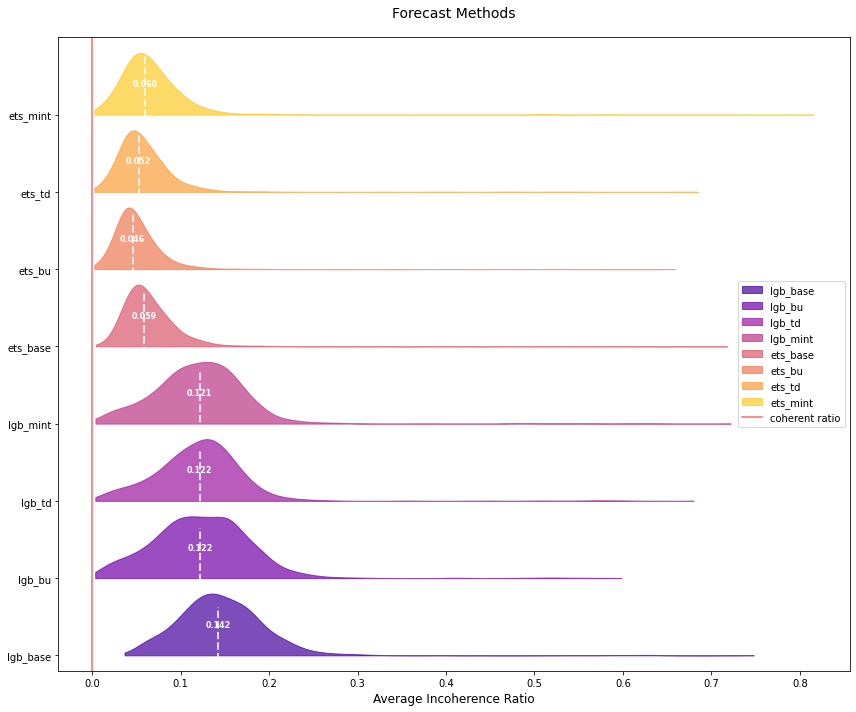

"\nfig2, ax2 = plot_violin_horizontal(df)\nplt.savefig('distribution_violin.png', dpi=300, bbox_inches='tight')\nplt.show()\n\nfig3, ax3 = plot_heatmap_distributions(df)\nplt.savefig('distribution_heatmap.png', dpi=300, bbox_inches='tight')\nplt.show()"

In [59]:
# ==================== 使用示例 ====================

# 假设 df 是你的数据（index是series_id，columns是方法）
# 模拟数据（替换为你的实际数据）
df = pd.DataFrame(a)

# 绘制（选择你喜欢的方法）
fig1, ax1 = plot_horizontal_distributions(df, palette='plasma')
plt.savefig('distribution_ridgeline.png', dpi=300, bbox_inches='tight')
plt.show()
'''
fig2, ax2 = plot_violin_horizontal(df)
plt.savefig('distribution_violin.png', dpi=300, bbox_inches='tight')
plt.show()

fig3, ax3 = plot_heatmap_distributions(df)
plt.savefig('distribution_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()'''

### 

## Mean incoherence summary

In [ ]:
results.reset_index()